In [155]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from scipy.stats import zscore
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, auc

# Use a Python notebook & Load the dataset

In [156]:
parkinsons_df = pd.read_csv('parkinsons.data')
parkinsons_df.sample(10)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
148,phon_R01_S35_3,188.620,216.302,165.982,0.01719,0.00009,0.00996,0.01027,0.02987,0.07118,...,0.10422,0.08069,12.298,1,0.552870,0.764036,-3.377325,0.335357,3.274865,0.418646
180,phon_R01_S44_4,150.440,163.441,144.736,0.00396,0.00003,0.00206,0.00233,0.00619,0.02551,...,0.03964,0.00611,23.133,1,0.352396,0.759320,-6.261446,0.183218,2.264226,0.144105
116,phon_R01_S27_2,158.219,442.557,71.948,0.00476,0.00003,0.00214,0.00207,0.00642,0.01458,...,0.01818,0.01554,26.356,1,0.450798,0.653823,-6.051233,0.273280,2.640798,0.170106
129,phon_R01_S32_2,120.078,126.632,105.667,0.00270,0.00002,0.00116,0.00135,0.00349,0.01022,...,0.01428,0.00487,26.369,1,0.491345,0.718839,-5.892061,0.195976,2.108873,0.183572
184,phon_R01_S49_2,116.848,217.552,99.503,0.00531,0.00005,0.00260,0.00346,0.00780,0.01795,...,0.02429,0.01179,22.085,0,0.663842,0.656516,-5.198864,0.206768,2.120412,0.252404
28,phon_R01_S06_5,155.358,227.383,80.055,0.00310,0.00002,0.00159,0.00176,0.00476,0.01718,...,0.02307,0.00677,25.970,1,0.470478,0.676258,-7.120925,0.279789,2.241742,0.108514
89,phon_R01_S21_6,179.711,225.930,144.878,0.00709,0.00004,0.00391,0.00419,0.01172,0.04313,...,0.06892,0.07223,11.866,1,0.590951,0.745526,-4.379411,0.375531,3.671155,0.332086
52,phon_R01_S13_5,128.001,138.052,122.080,0.00436,0.00003,0.00137,0.00166,0.00411,0.02297,...,0.03969,0.00481,24.692,0,0.459766,0.766204,-7.072419,0.220434,1.972297,0.119308
142,phon_R01_S34_3,198.458,219.290,148.691,0.00376,0.00002,0.00182,0.00215,0.00546,0.03527,...,0.06165,0.01728,18.702,1,0.606273,0.661735,-5.585259,0.310746,2.465528,0.209863
164,phon_R01_S39_6,102.273,142.830,85.902,0.00907,0.00009,0.00493,0.00461,0.01480,0.02814,...,0.04736,0.03882,18.447,1,0.671378,0.674562,-2.929379,0.396746,2.560422,0.367233


# It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset

In [157]:
parkinsons_df.shape

(195, 24)

In [158]:
parkinsons_df.dtypes

name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object

In [159]:
parkinsons_df.isna().any()

name                False
MDVP:Fo(Hz)         False
MDVP:Fhi(Hz)        False
MDVP:Flo(Hz)        False
MDVP:Jitter(%)      False
MDVP:Jitter(Abs)    False
MDVP:RAP            False
MDVP:PPQ            False
Jitter:DDP          False
MDVP:Shimmer        False
MDVP:Shimmer(dB)    False
Shimmer:APQ3        False
Shimmer:APQ5        False
MDVP:APQ            False
Shimmer:DDA         False
NHR                 False
HNR                 False
status              False
RPDE                False
DFA                 False
spread1             False
spread2             False
D2                  False
PPE                 False
dtype: bool

# Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations?

In [160]:
parkinsons_df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [178]:
parkinsons_df.std()

MDVP:Fo(Hz)         41.390065
MDVP:Fhi(Hz)        91.491548
MDVP:Flo(Hz)        43.521413
MDVP:Jitter(%)       0.004848
MDVP:Jitter(Abs)     0.000035
MDVP:RAP             0.002968
MDVP:PPQ             0.002759
Jitter:DDP           0.008903
MDVP:Shimmer         0.018857
MDVP:Shimmer(dB)     0.194877
Shimmer:APQ3         0.010153
Shimmer:APQ5         0.012024
MDVP:APQ             0.016947
Shimmer:DDA          0.030459
NHR                  0.040418
HNR                  4.425764
status               0.431878
RPDE                 0.103942
DFA                  0.055336
spread1              1.090208
spread2              0.083406
D2                   0.382799
PPE                  0.090119
dtype: float64

In [162]:
rearranged_df = parkinsons_df.drop("status",axis=1) 


In [168]:
rearranged_df['status']=parkinsons_df['status']

In [169]:
rearranged_df.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356,-0.383535
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543,-0.166136
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071,-0.380200
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543,0.278220
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162,0.338653
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999,0.266668
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647,0.288698
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005,0.266646
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771,0.367430
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058,0.350697


In [174]:
rearranged_df=rearranged_df.drop('name',axis=1)

In [182]:
rearranged_df[rearranged_df.columns.tolist()]=np.where(rearranged_df[rearranged_df.columns.tolist()].quantile(.75)*1.5<rearranged_df[rearranged_df.columns.tolist()],rearranged_df[rearranged_df.columns.tolist()].median(),rearranged_df[rearranged_df.columns.tolist()])
rearranged_df.std()

MDVP:Fo(Hz)         4.139006e+01
MDVP:Fhi(Hz)        4.528519e+01
MDVP:Flo(Hz)        2.401816e+01
MDVP:Jitter(%)      1.813012e-03
MDVP:Jitter(Abs)    1.425283e-05
MDVP:RAP            1.023813e-03
MDVP:PPQ            1.016286e-03
Jitter:DDP          3.070643e-03
MDVP:Shimmer        8.542187e-03
MDVP:Shimmer(dB)    8.030540e-02
Shimmer:APQ3        4.641099e-03
Shimmer:APQ5        5.370228e-03
MDVP:APQ            6.675154e-03
Shimmer:DDA         1.392368e-02
NHR                 9.052617e-03
HNR                 4.425764e+00
RPDE                1.039417e-01
DFA                 5.533583e-02
spread1             1.869976e-14
spread2             7.926239e-02
D2                  3.827990e-01
PPE                 6.682556e-02
status              4.318780e-01
dtype: float64

In [185]:
rearranged_df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE,status
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,1.950000e+02,195.000000,195.000000,195.000000,195.000000
mean,154.228641,178.626344,103.105333,0.004930,0.000033,0.002523,0.002713,0.007570,0.023305,0.216826,...,0.036733,0.014039,21.885974,0.498536,0.718099,-5.684397e+00,0.223292,2.381826,0.189815,0.753846
std,41.390065,45.285185,24.018159,0.001813,0.000014,0.001024,0.001016,0.003071,0.008542,0.080305,...,0.013924,0.009053,4.425764,0.103942,0.055336,1.869976e-14,0.079262,0.382799,0.066826,0.431878
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.256570,0.574282,-5.684397e+00,0.006274,1.423287,0.044539,0.000000
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,0.421306,0.674758,-5.684397e+00,0.174351,2.099125,0.137451,1.000000
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,0.495954,0.722254,-5.684397e+00,0.218885,2.361532,0.194052,1.000000
75%,182.769000,211.782500,114.748000,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,25.075500,0.587562,0.761881,-5.684397e+00,0.270253,2.636456,0.232365,1.000000
max,260.105000,272.210000,168.793000,0.009230,0.000060,0.004930,0.005140,0.014800,0.043740,0.422000,...,0.070080,0.036900,33.047000,0.685151,0.825288,-5.684397e+00,0.397749,3.671155,0.344834,1.000000


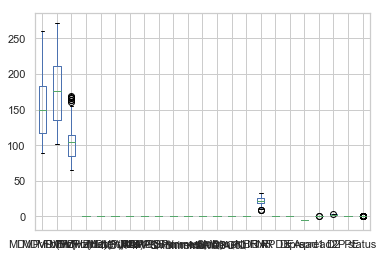

In [190]:
rearranged_df.boxplot()

In [ ]:
import seaborn as sns 
bplot=sns.boxplot(data=rearranged_df,
                 width=0.5,
                 palette="colorblind")
bplot.set_xticklabels(bplot.get_xticklabels(),rotation=30)

In [ ]:
bplot=sns.boxplot(data=rearranged_df[['MDVP:Fhi(Hz)']],
                 width=0.5,
                 palette="colorblind")
bplot.set_xticklabels(bplot.get_xticklabels(),rotation=30)

# Split the dataset into training and test set in the ratio of 70:30

In [ ]:
rearranged_df=rearranged_df.drop("name",axis=1)
X = rearranged_df.drop("status", axis=1)
y = rearranged_df["status"]
test_size = 0.30 # taking 70:30 training and test set
seed = 7  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

# Create the model using “entropy” method of reducing the entropy and fit it to training data

In [ ]:
model = DecisionTreeClassifier(criterion='entropy',random_state=0)
model.fit(X_train,y_train)

# Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab

In [ ]:
y_predict = model.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print("accuracy: ", accuracy)
metrics.confusion_matrix(y_predict, y_test)

# Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help?

In [ ]:
dt=DecisionTreeClassifier(max_depth=10,min_samples_leaf=5)
dt.fit(X_train,y_train)


In [ ]:
y_predict = dt.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print("accuracy: ", accuracy)

# Next implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? 

In [ ]:
rf=RandomForestClassifier(n_estimators=5,max_depth=5,min_samples_leaf=2)
rf.fit(X_train,y_train)

In [ ]:
y_predict = rf.predict(X_test)
accuracy=metrics.accuracy_score(y_test,y_predict)
print("accuracy: ", accuracy)